
Room1 Samples: 16541
Room2 Samples: 15477
Room3 Samples: 15200

Training Shape : (16541, 10)
Room2 Test Shape: (15477, 10)
Room3 Test Shape: (15200, 10)
checkpoint directory created: ./model
saving model version 0.0

TRAINING KAN MODEL


| train_loss: 9.23e-02 | test_loss: 1.43e-01 | reg: 3.88e+01 | : 100%|█| 100/100 [45:47<00:00, 27.48


saving model version 0.1


| train_loss: 9.06e-02 | test_loss: 1.41e-01 | reg: 3.91e+01 | : 100%|█| 50/50 [23:58<00:00, 28.77s/


saving model version 0.2
saving model version 0.3

PRUNING SUCCESSFUL


| train_loss: 1.57e-01 | test_loss: 1.90e-01 | reg: 2.54e+01 | : 100%|█| 20/20 [11:33<00:00, 34.69s/
/usr/local/lib/python3.12/dist-packages/kan/MultKAN.py:816: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1858.)
  self.subnode_actscale.append(torch.std(x, dim=0).detach())
/usr/local/lib/python3.12/dist-packages/kan/MultKAN.py:826: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1858.)
  input_range = torch.std(preacts, dim=0) + 0.1
/usr/local/lib/python3.12/dist-packages/kan/MultKAN.py:827: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered int

saving model version 0.4


EVALUATION ON ROOM2

KAN RESULTS

Roll
MAE  : 0.7517 Degree
RMSE : 2.4405 Degree
R2   : 0.9010

Pitch
MAE  : 0.7659 Degree
RMSE : 2.2296 Degree
R2   : 0.9307

Yaw
MAE  : 3.8521 Degree
RMSE : 30.2498 Degree
R2   : 0.8883

MADGWICK RESULTS

Roll
MAE  : 12.0664 Degree
RMSE : 20.4714 Degree
R2   : -5.9629

Pitch
MAE  : 9.3171 Degree
RMSE : 15.4320 Degree
R2   : -2.3209

Yaw
MAE  : 95.7868 Degree
RMSE : 125.5917 Degree
R2   : -0.9252

QUATERNION ERROR METRICS

KAN
Quaternion MAE  : 1.9347 Degree
Quaternion RMSE : 5.6661 Degree
Quaternion Mean : 1.9347 Degree

Madgwick
Quaternion MAE  : 79.7115 Degree
Quaternion RMSE : 92.8876 Degree
Quaternion Mean : 79.7115 Degree


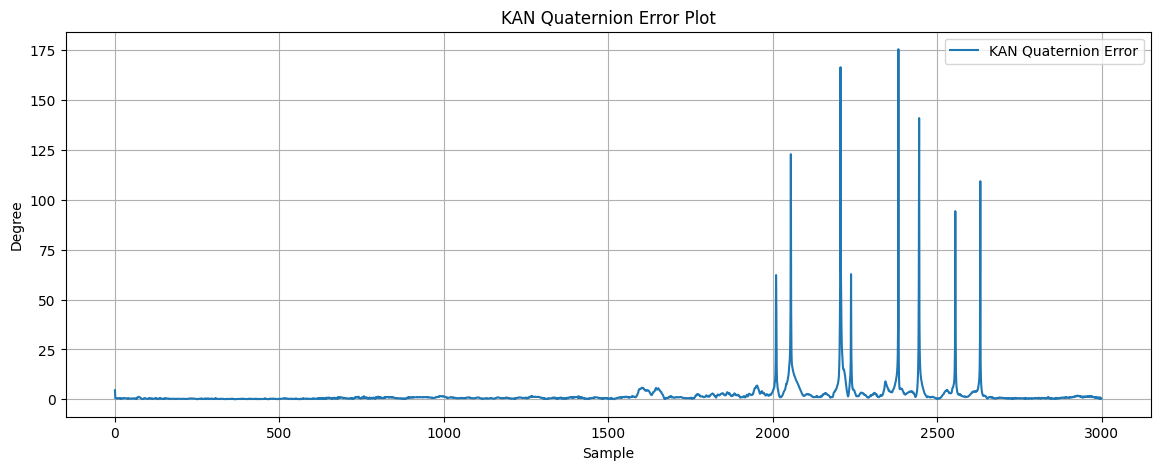

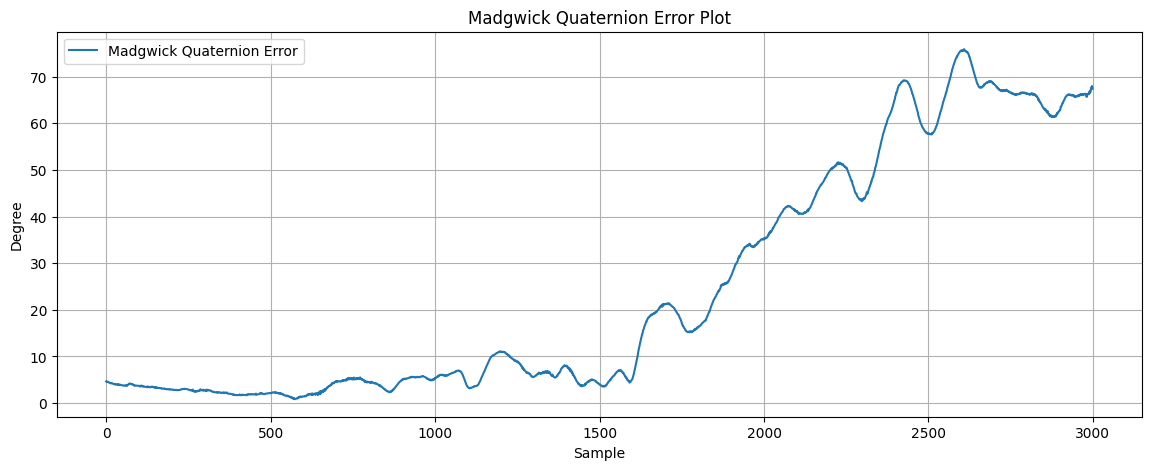

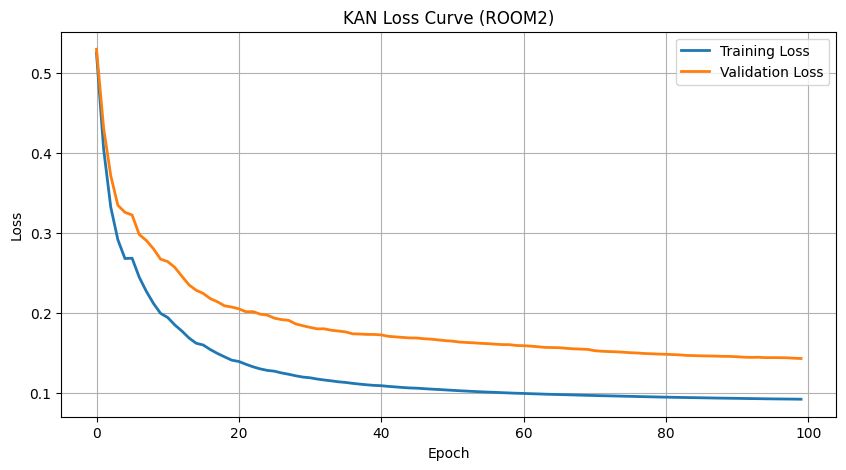

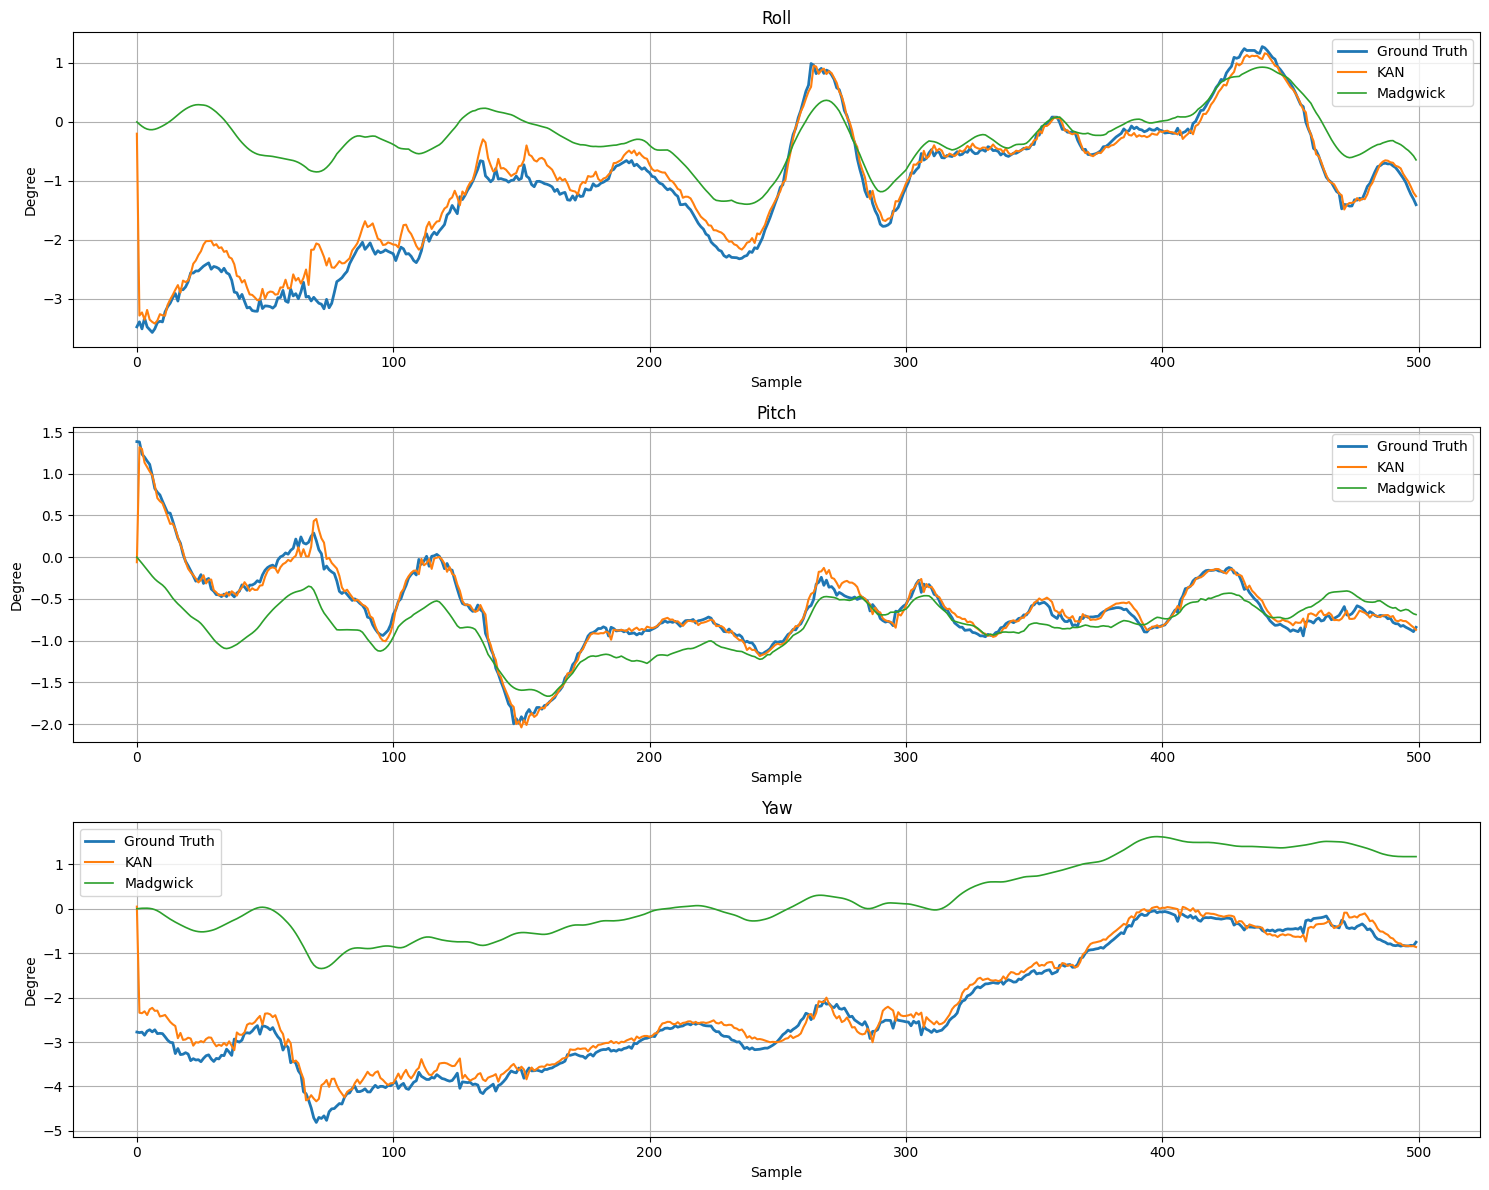



EVALUATION ON ROOM3


/usr/local/lib/python3.12/dist-packages/kan/MultKAN.py:816: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1858.)
  self.subnode_actscale.append(torch.std(x, dim=0).detach())
/usr/local/lib/python3.12/dist-packages/kan/MultKAN.py:826: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1858.)
  input_range = torch.std(preacts, dim=0) + 0.1
/usr/local/lib/python3.12/dist-packages/kan/MultKAN.py:827: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1858.)
  output_range_spline = torch.std(posta


KAN RESULTS

Roll
MAE  : 0.9976 Degree
RMSE : 3.0684 Degree
R2   : 0.8089

Pitch
MAE  : 1.0588 Degree
RMSE : 2.9055 Degree
R2   : 0.9436

Yaw
MAE  : 9.6197 Degree
RMSE : 53.1838 Degree
R2   : 0.7517

MADGWICK RESULTS

Roll
MAE  : 20.9688 Degree
RMSE : 32.6396 Degree
R2   : -20.6203

Pitch
MAE  : 8.7967 Degree
RMSE : 14.3499 Degree
R2   : -0.3758

Yaw
MAE  : 114.4751 Degree
RMSE : 154.0768 Degree
R2   : -1.0843

QUATERNION ERROR METRICS

KAN
Quaternion MAE  : 2.4921 Degree
Quaternion RMSE : 5.7537 Degree
Quaternion Mean : 2.4921 Degree

Madgwick
Quaternion MAE  : 79.3461 Degree
Quaternion RMSE : 93.4848 Degree
Quaternion Mean : 79.3461 Degree


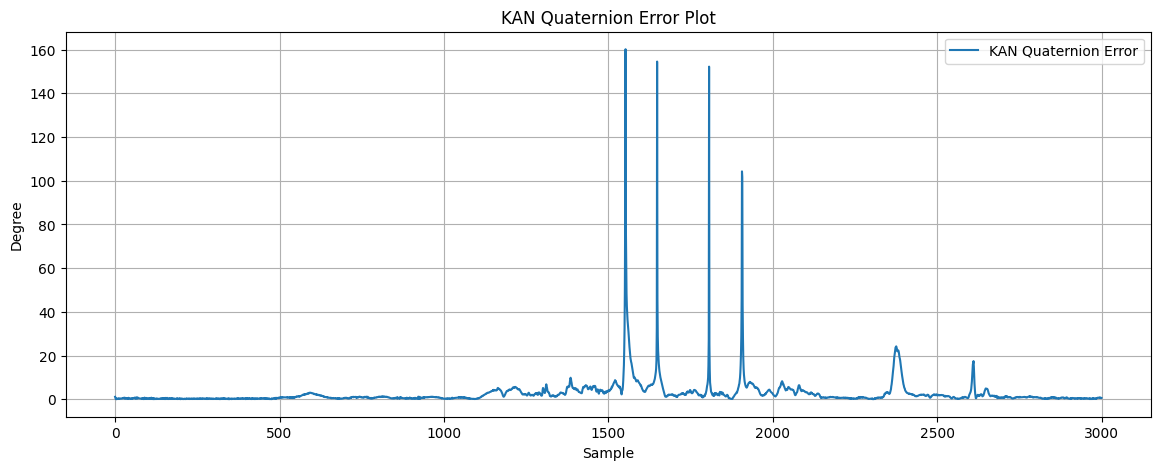

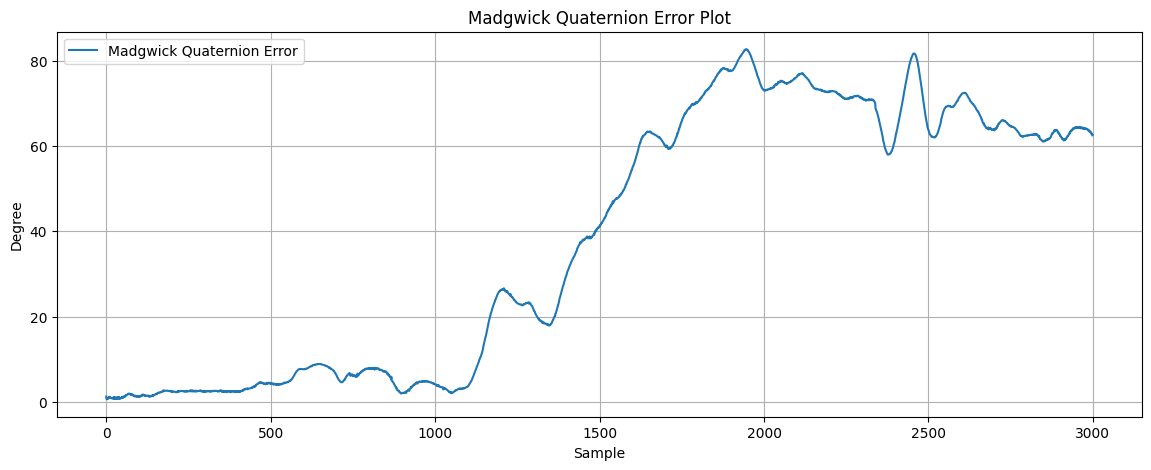

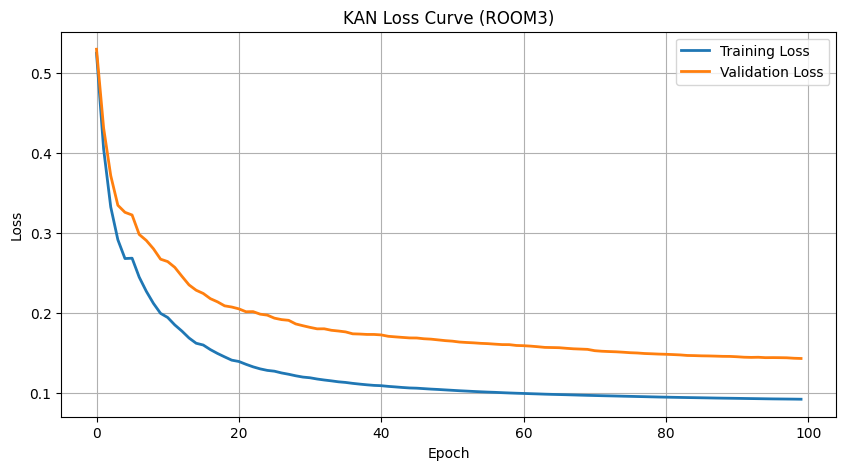

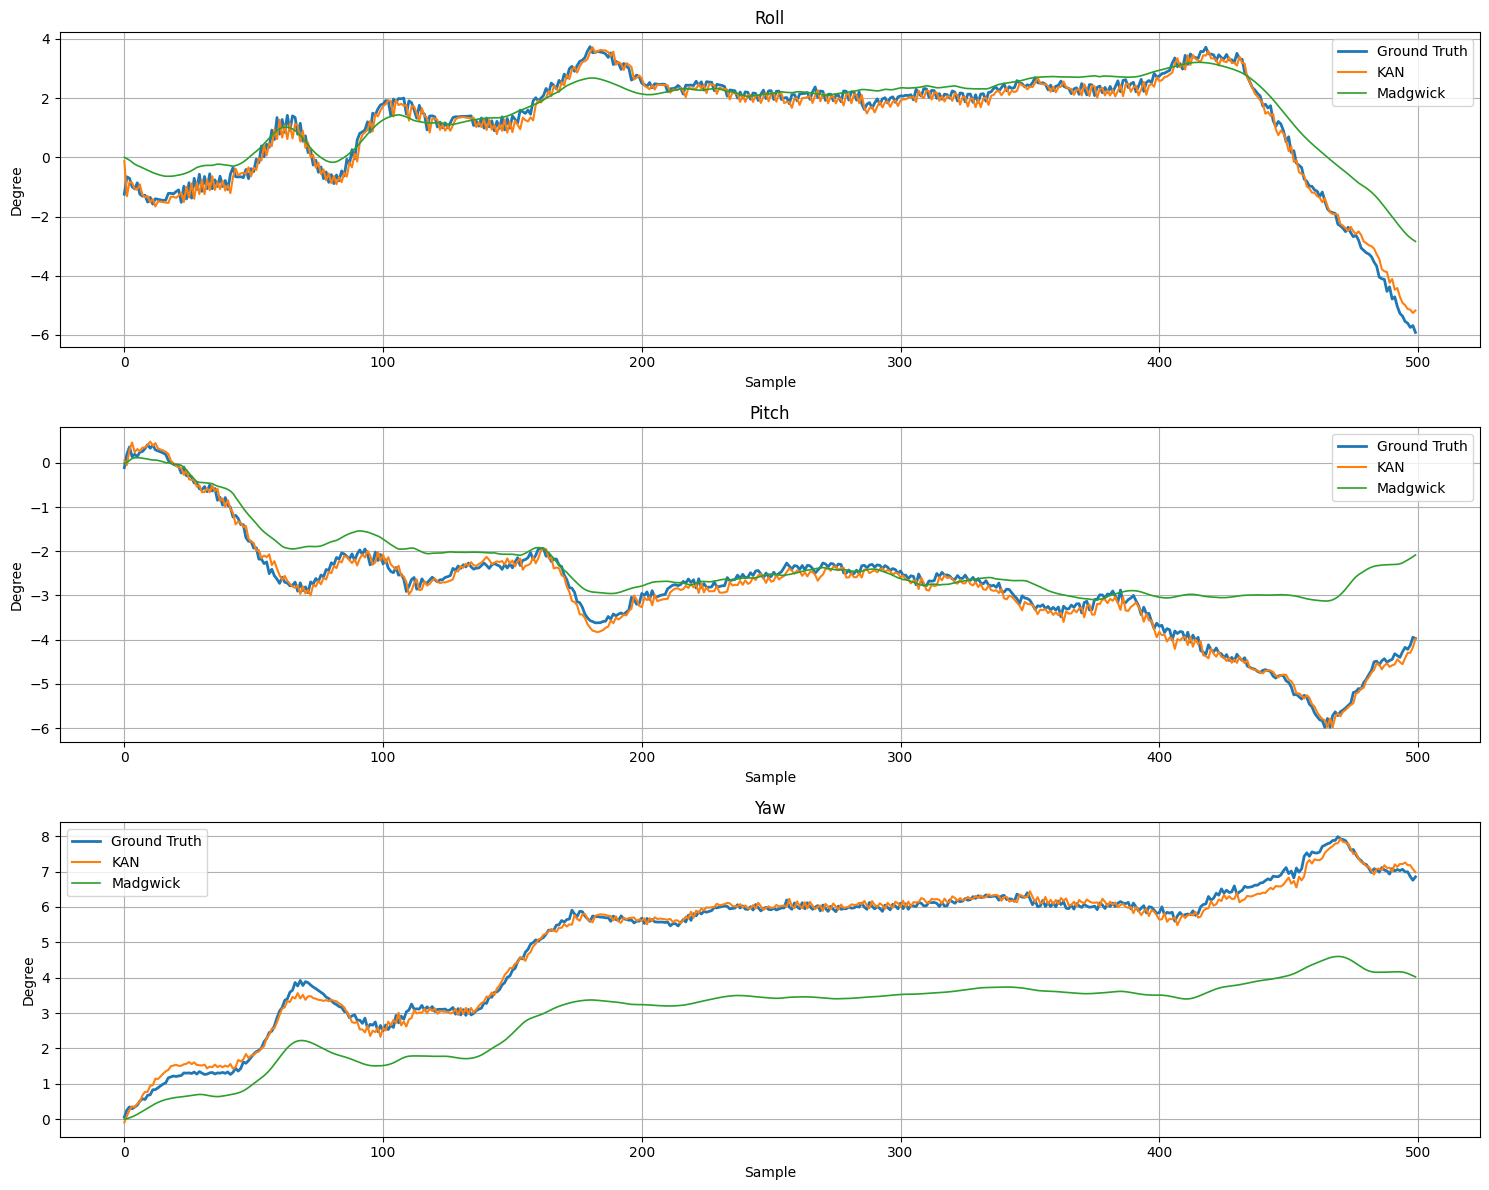

In [ ]:
import pandas as pd
import numpy as np
import torch
import kan
import matplotlib.pyplot as plt

from ahrs.filters import Madgwick
from scipy.spatial.transform import Rotation as R

from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# =========================================================
# RANDOM SEED
# =========================================================

SEED = 42

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.set_default_dtype(torch.float64)

# =========================================================
# LOAD DATA FUNCTION
# =========================================================

def load_room_data(gt_path, imu_path):

    # -----------------------------
    # LOAD GROUND TRUTH
    # -----------------------------

    gt = pd.read_csv(gt_path)

    gt.rename(
        columns={'# timestamp[ns]': 'timestamp[ns]'},
        inplace=True
    )

    gt['timestamp[ns]'] = pd.to_numeric(
        gt['timestamp[ns]']
    )

    gt.sort_values(
        'timestamp[ns]',
        inplace=True
    )

    # -----------------------------
    # LOAD IMU
    # -----------------------------

    imu_col_names = [
        'timestamp[ns]',
        'w.x',
        'w.y',
        'w.z',
        'a.x',
        'a.y',
        'a.z'
    ]

    imu = pd.read_csv(
        imu_path,
        sep=r'\s+',
        comment='#',
        names=imu_col_names
    )

    imu['timestamp[ns]'] = pd.to_numeric(
        imu['timestamp[ns]']
    )

    imu.sort_values(
        'timestamp[ns]',
        inplace=True
    )

    # -----------------------------
    # LINEAR INTERPOLATION SYNCHRONIZATION
    # -----------------------------

    # Set timestamp as index
    gt = gt.sort_values('timestamp[ns]')
    imu = imu.sort_values('timestamp[ns]')

    imu_interp = imu.set_index('timestamp[ns]')

    # Add GT timestamps into IMU index
    imu_interp = imu_interp.reindex(
        imu_interp.index.union(gt['timestamp[ns]'])
    ).sort_index()

    # Linear interpolation
    imu_interp = imu_interp.interpolate(method='index')

    # Keep only GT timestamps
    imu_interp = imu_interp.loc[gt['timestamp[ns]']].reset_index()

    # Merge GT + interpolated IMU
    data = pd.merge(
        gt,
        imu_interp,
        on='timestamp[ns]',
        how='inner'
    )

    # -----------------------------
    # REMOVE NaN
    # -----------------------------

    critical_columns = [
        'qx',
        'qy',
        'qz',
        'qw',
        'w.x',
        'w.y',
        'w.z',
        'a.x',
        'a.y',
        'a.z'
    ]

    data.dropna(
        subset=critical_columns,
        inplace=True
    )

    data.reset_index(
        drop=True,
        inplace=True
    )

    return data

# =========================================================
# LOAD ROOMS SEPARATELY
# =========================================================

room1 = load_room_data(
    "r1_gt_imu.csv",
    "r1_imu.txt"
)

room2 = load_room_data(
    "r2_gt_imu.csv",
    "r2_imu.txt"
)

room3 = load_room_data(
    "r3_gt_imu.csv",
    "r3_imu.txt"
)

print("\nRoom1 Samples:", len(room1))
print("Room2 Samples:", len(room2))
print("Room3 Samples:", len(room3))

# =========================================================
# FEATURES
# =========================================================

feature_names = [
    'w.x',
    'w.y',
    'w.z',
    'a.x',
    'a.y',
    'a.z'
]

# =========================================================
# TRAIN DATA (ROOM1)
# =========================================================

X_train_np = room1[feature_names].values

y_train_np = room1[
    ['qx', 'qy', 'qz', 'qw']
].values

q_prev_train = np.zeros_like(y_train_np)

q_prev_train[1:] = y_train_np[:-1]

# first timestep identity quaternion
q_prev_train[0] = np.array([0, 0, 0, 1])

# concatenate IMU + previous quaternion
X_train_np = np.concatenate(
    [X_train_np, q_prev_train],
    axis=1
)

# =========================================================
# TEST DATA ROOM2
# =========================================================

X_test_r2_np = room2[feature_names].values

y_test_r2_np = room2[
    ['qx', 'qy', 'qz', 'qw']
].values

q_prev_r2 = np.zeros_like(y_test_r2_np)

q_prev_r2[1:] = y_test_r2_np[:-1]

q_prev_r2[0] = np.array([0, 0, 0, 1])

X_test_r2_np = np.concatenate(
    [X_test_r2_np, q_prev_r2],
    axis=1
)

# =========================================================
# TEST DATA ROOM3
# =========================================================

X_test_r3_np = room3[feature_names].values

y_test_r3_np = room3[
    ['qx', 'qy', 'qz', 'qw']
].values

# previous quaternion for room3
q_prev_r3 = np.zeros_like(y_test_r3_np)

q_prev_r3[1:] = y_test_r3_np[:-1]

q_prev_r3[0] = np.array([0, 0, 0, 1])

X_test_r3_np = np.concatenate(
    [X_test_r3_np, q_prev_r3],
    axis=1
)

print("\nTraining Shape :", X_train_np.shape)
print("Room2 Test Shape:", X_test_r2_np.shape)
print("Room3 Test Shape:", X_test_r3_np.shape)

# =========================================================
# NORMALIZATION
# ONLY INPUTS ARE SCALED
# QUATERNIONS ARE NOT SCALED
# =========================================================

scaler_x = MinMaxScaler()

X_train = torch.tensor(
    scaler_x.fit_transform(X_train_np)
)

X_test_r2 = torch.tensor(
    scaler_x.transform(X_test_r2_np)
)

X_test_r3 = torch.tensor(
    scaler_x.transform(X_test_r3_np)
)

# IMPORTANT:
# DO NOT SCALE QUATERNIONS

y_train = torch.tensor(y_train_np)

y_test_r2 = torch.tensor(y_test_r2_np)

y_test_r3 = torch.tensor(y_test_r3_np)

# =========================================================
# PYKAN DATASET
# VALIDATION SET = ROOM2
# =========================================================

dataset = {
    'train_input': X_train,
    'train_label': y_train,
    'test_input': X_test_r2,
    'test_label': y_test_r2
}

# =========================================================
# CREATE KAN MODEL
# =========================================================

model = kan.KAN(
    width=[10,16,16, 4],
    grid=5,
    k=3,
    seed=SEED
)

# =========================================================
# QUATERNION LOSS
# =========================================================

def quat_angle_loss(y_pred, y_true):

    # normalize predictions
    epsilon = 1e-6 # Added epsilon for numerical stability
    y_pred = y_pred / (torch.norm(
        y_pred,
        dim=1,
        keepdim=True
    ) + epsilon)

    # normalize GT

    y_true = y_true / (torch.norm(
        y_true,
        dim=1,
        keepdim=True
    ) + epsilon)

    # dot product

    dot = torch.sum(
        y_pred * y_true,
        dim=1
    )

    # q == -q

    dot = torch.abs(dot)

    # clamp

    dot = torch.clamp(
        dot,
        -1.0,
        1.0
    )

    # angular loss

    theta = 2 * torch.acos(dot)

    return torch.mean(theta)

# =========================================================
# TRAIN MODEL
# =========================================================

print("\n==============================")
print("TRAINING KAN MODEL")
print("==============================")

results = model.fit(
    dataset,
    opt="LBFGS",
    steps=100,
    loss_fn=quat_angle_loss
)

# =========================================================
# PRUNE MODEL
# =========================================================

#model = model.prune()

result = model.fit(
    dataset,
    opt="LBFGS",
    steps=50,
    loss_fn=quat_angle_loss
)

try:

    model = model.prune()

    print("\nPRUNING SUCCESSFUL")

    model.fit(
        dataset,
        opt="LBFGS",
        steps=20,
        loss_fn=quat_angle_loss
    )

except Exception as e:

    print("\nPRUNING FAILED")

    print(e)

    print("\nCONTINUING WITHOUT PRUNING")

# =========================================================
# EVALUATION FUNCTION
# =========================================================

def evaluate_room(
    room_name,
    X_test_np,
    X_test_tensor,
    y_true_quat
):

    print("\n")
    print("========================================")
    print(f"EVALUATION ON {room_name}")
    print("========================================")

    # =====================================================
    # KAN PREDICTION
    # =====================================================

    # =====================================================
    # KAN SEQUENTIAL PREDICTION
    # USING PREVIOUS PREDICTED QUATERNION
    # =====================================================

    outputs = []

    # initial quaternion
    q_prev = torch.tensor(
        [[0,0,0,1]],
        dtype=torch.float64
    )

    with torch.no_grad():

        for i in range(len(X_test_tensor)):

            # current IMU sample
            x = X_test_tensor[i].unsqueeze(0)

            # concatenate IMU + previous quaternion
            x_aug = torch.cat(
                [x, q_prev],
                dim=1
            )

            # model prediction
            q_pred = model(x_aug)

            # normalize quaternion
            q_pred = q_pred / torch.norm(
                q_pred,
                dim=1,
                keepdim=True
            )

            outputs.append(
                q_pred.cpu().numpy()
            )

            # feedback prediction
            q_prev = q_pred.detach()

    # convert list to numpy
    y_pred_quat = np.vstack(outputs)

    # =====================================================
    # EULER CONVERSION
    # =====================================================

    y_pred_euler = R.from_quat(
        y_pred_quat
    ).as_euler(
        'xyz',
        degrees=True
    )

    y_true_euler = R.from_quat(
        y_true_quat
    ).as_euler(
        'xyz',
        degrees=True
    )

    # =====================================================
    # KAN METRICS
    # =====================================================

    print("\nKAN RESULTS")

    labels = ['Roll', 'Pitch', 'Yaw']

    for i in range(3):

        mae = mean_absolute_error(
            y_true_euler[:,i],
            y_pred_euler[:,i]
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_true_euler[:,i],
                y_pred_euler[:,i]
            )
        )

        r2 = r2_score(
            y_true_euler[:,i],
            y_pred_euler[:,i]
        )

        print(f"\n{labels[i]}")

        print(f"MAE  : {mae:.4f} Degree")

        print(f"RMSE : {rmse:.4f} Degree")

        print(f"R2   : {r2:.4f}")

    # =====================================================
    # MADGWICK
    # =====================================================

    gyro = X_test_np[:,0:3]

    acc = X_test_np[:,3:6]

    madgwick = Madgwick(
        frequency=200
    )

    Q = np.zeros((len(gyro), 4))

    Q[0] = np.array([1,0,0,0])

    for t in range(1, len(gyro)):

        Q[t] = madgwick.updateIMU(
            q=Q[t-1],
            gyr=gyro[t],
            acc=acc[t]
        )

    mad_quat = np.column_stack((
        Q[:,1],
        Q[:,2],
        Q[:,3],
        Q[:,0]
    ))

    mad_euler = R.from_quat(
        mad_quat
    ).as_euler(
        'xyz',
        degrees=True
    )

    # =====================================================
    # MADGWICK METRICS
    # =====================================================

    print("\nMADGWICK RESULTS")

    for i in range(3):

        mae = mean_absolute_error(
            y_true_euler[:,i],
            mad_euler[:,i]
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_true_euler[:,i],
                mad_euler[:,i]
            )
        )

        r2 = r2_score(
            y_true_euler[:,i],
            mad_euler[:,i]
        )

        print(f"\n{labels[i]}")

        print(f"MAE  : {mae:.4f} Degree")

        print(f"RMSE : {rmse:.4f} Degree")

        print(f"R2   : {r2:.4f}")

    # =====================================================
    # QUATERNION ERROR
    # =====================================================

    def quaternion_angle_error(
        q_gt,
        q_pred
    ):

        q_gt = q_gt / np.linalg.norm(
            q_gt,
            axis=1,
            keepdims=True
        )

        q_pred = q_pred / np.linalg.norm(
            q_pred,
            axis=1,
            keepdims=True
        )

        dot = np.sum(
            q_gt * q_pred,
            axis=1
        )

        dot = np.abs(dot)

        dot = np.clip(
            dot,
            -1.0,
            1.0
        )

        theta = 2 * np.arccos(dot)

        return theta

   # =====================================================
   # QUATERNION MAE & RMSE
   # =====================================================

    kan_theta = quaternion_angle_error(
        y_true_quat,
        y_pred_quat
    )

    mad_theta = quaternion_angle_error(
        y_true_quat,
        mad_quat
    )

    # Convert radian -> degree
    kan_theta_deg = np.degrees(kan_theta)
    mad_theta_deg = np.degrees(mad_theta)

    # KAN
    kan_quat_mae = np.mean(np.abs(kan_theta_deg))
    kan_quat_rmse = np.sqrt(np.mean(kan_theta_deg**2))

    # Madgwick
    mad_quat_mae = np.mean(np.abs(mad_theta_deg))
    mad_quat_rmse = np.sqrt(np.mean(mad_theta_deg**2))

    kan_quat_mean = np.mean(kan_theta_deg)
    mad_quat_mean = np.mean(mad_theta_deg)

    print("\nQUATERNION ERROR METRICS")

    print("\nKAN")
    print(f"Quaternion MAE  : {kan_quat_mae:.4f} Degree")
    print(f"Quaternion RMSE : {kan_quat_rmse:.4f} Degree")
    print(f"Quaternion Mean : {kan_quat_mean:.4f} Degree")

    print("\nMadgwick")
    print(f"Quaternion MAE  : {mad_quat_mae:.4f} Degree")
    print(f"Quaternion RMSE : {mad_quat_rmse:.4f} Degree")
    print(f"Quaternion Mean : {mad_quat_mean:.4f} Degree")

    # =====================================================
    # QUATERNION ERROR PLOTS
    # =====================================================

    plt.figure(figsize=(14,5))
    plt.plot(kan_theta_deg[:3000], label='KAN Quaternion Error')
    plt.xlabel("Sample")
    plt.ylabel("Degree")
    plt.title("KAN Quaternion Error Plot")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(14,5))
    plt.plot(mad_theta_deg[:3000], label='Madgwick Quaternion Error')
    plt.xlabel("Sample")
    plt.ylabel("Degree")
    plt.title("Madgwick Quaternion Error Plot")
    plt.legend()
    plt.grid(True)
    plt.show()

    # =====================================================
    # TRAINING LOSS
    # =====================================================

    train_loss = results['train_loss']

    test_loss = results['test_loss']

    plt.figure(figsize=(10,5))

    plt.plot(
        train_loss,
        label='Training Loss',
        linewidth=2
    )

    plt.plot(
        test_loss,
        label='Validation Loss',
        linewidth=2
    )

    plt.xlabel("Epoch")

    plt.ylabel("Loss")

    plt.title(
        f"KAN Loss Curve ({room_name})"
    )

    plt.legend()

    plt.grid(True)

    plt.show()

    # =====================================================
    # LINE PLOT
    # =====================================================

    N = min(500, len(y_true_euler))

    time_axis = np.arange(N)

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(15,12)
    )

    for i in range(3):

        ax = axes[i]

        # Ground Truth

        ax.plot(
            time_axis,
            y_true_euler[:N,i],
            label='Ground Truth',
            linewidth=2
        )

        # KAN

        ax.plot(
            time_axis,
            y_pred_euler[:N,i],
            label='KAN',
            linewidth=1.5
        )

        # Madgwick

        ax.plot(
            time_axis,
            mad_euler[:N,i],
            label='Madgwick',
            linewidth=1.2
        )

        ax.set_title(labels[i])

        ax.set_xlabel("Sample")

        ax.set_ylabel("Degree")

        ax.legend()

        ax.grid(True)

    plt.tight_layout()

    plt.show()

# =========================================================
# TEST ROOM2
# =========================================================

evaluate_room(
    room_name="ROOM2",
    X_test_np=X_test_r2_np,
    X_test_tensor=X_test_r2,
    y_true_quat=y_test_r2_np
)

# =========================================================
# TEST ROOM3
# =========================================================

evaluate_room(
    room_name="ROOM3",
    X_test_np=X_test_r3_np,
    X_test_tensor=X_test_r3,
    y_true_quat=y_test_r3_np
)